In [13]:
###########################################
#                 IMPORTS                 #
###########################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
###########################################
#                LOAD DATA                #
###########################################

# Load training and test datasets
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

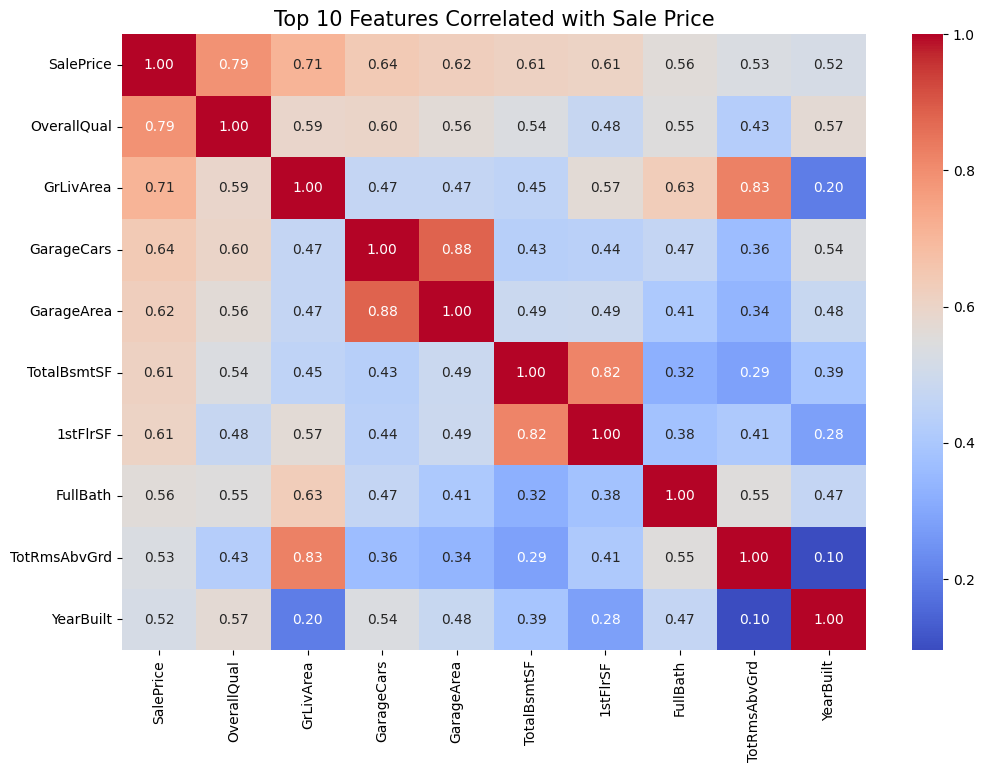

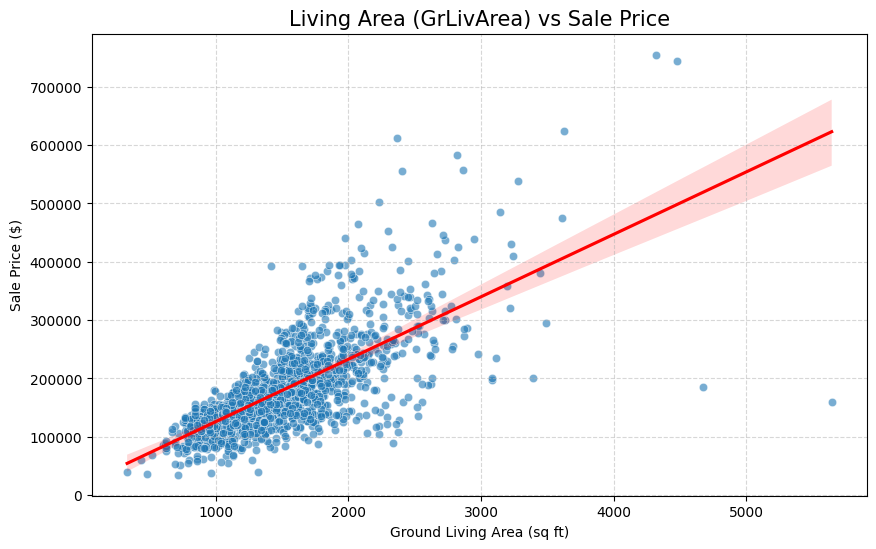

In [21]:
###########################################
#       VISUAL DATA ANALYSIS (EDA)        #
###########################################

# 1. Heatmap de corrélation (Top 10 variables)
plt.figure(figsize=(12, 8))
# On calcule la corrélation et on sélectionne les 10 plus fortes par rapport au prix
correlation_matrix = train.select_dtypes(include=[np.number]).corr()
cols = correlation_matrix['SalePrice'].sort_values(ascending=False).head(10).index

sns.heatmap(train[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Features Correlated with Sale Price', fontsize=15)
plt.show()

# 2. Relation Surface habitable vs Prix de vente
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', alpha=0.6)

# Ajout d'une ligne de tendance pour montrer la corrélation
sns.regplot(data=train, x='GrLivArea', y='SalePrice', scatter=False, color='red')

plt.title('Living Area (GrLivArea) vs Sale Price', fontsize=15)
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [4]:
###########################################
#        SEPARATE FEATURES & TARGET      #
###########################################

# Define target variable
y = train['SalePrice']

# Define feature set
X = train.drop('SalePrice', axis=1)

In [5]:
###########################################
#          DATA CLEANING & PREPROCESSING #
###########################################

# --- 1. Drop unnecessary columns ---
X = X.drop('Id', axis=1)
test = test.drop('Id', axis=1)

# --- 2. Separate numerical and categorical columns ---
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# --- 3. Handle missing values ---
# Numerical columns → fill NaN with median
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
test[num_cols] = test[num_cols].fillna(X[num_cols].median())

# Categorical columns → fill NaN with "None"
X[cat_cols] = X[cat_cols].fillna("None")
test[cat_cols] = test[cat_cols].fillna("None")

# --- 4. Encode categorical columns ---
# One-Hot Encoding
X = pd.get_dummies(X, columns=cat_cols)
test = pd.get_dummies(test, columns=cat_cols)

# --- 5. Align test set with X columns ---
test = test.reindex(columns=X.columns, fill_value=0)


In [6]:
###########################################
#          TRAIN / VALIDATION SPLIT       #
###########################################

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
###########################################
#          LINEAR REGRESSION MODEL        #
###########################################

# --- 1. Initialize model ---
model = LinearRegression()

# --- 2. Train the model on training set ---
model.fit(X_train, y_train)

# --- 3. Predict on validation set ---
y_val_pred = model.predict(X_val)

# --- 4. Evaluate performance using RMSE ---
mse = mean_squared_error(y_val, y_val_pred)
rmse = mse ** 0.5
print("Validation RMSE:", rmse)

Validation RMSE: 65386.51166033954


In [11]:
###########################################
#          RANDOM FOREST MODEL            #
###########################################

# --- 1. Initialize model ---
# Random Forest with 100 trees by default
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
# --- 2. Train the model on training set ---
rf_model.fit(X_train, y_train)

# --- 3. Predict on validation set ---
y_val_pred_rf = rf_model.predict(X_val)

# --- 4. Evaluate performance using RMSE ---
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_rf = mse_rf ** 0.5
print("Validation RMSE (Random Forest):", rmse_rf)


Validation RMSE (Random Forest): 29014.69547022519


In [16]:
###########################################
#               XGBOOST MODEL             #
###########################################

# --- 1. Initialize model ---
# XGBoost with 500 trees
xgb_model = XGBRegressor(
    n_estimators=500,      # number of trees
    max_depth=6,           # maximum depth of each tree
    learning_rate=0.05,    # learning rate
    random_state=42
)

# --- 2. Train the model on training set ---
xgb_model.fit(X_train, y_train)

# --- 3. Predict on validation set ---
y_val_pred_xgb = xgb_model.predict(X_val)

# --- 4. Evaluate performance using RMSE ---
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
print("Validation RMSE (XGBoost):", rmse_xgb)


Validation RMSE (XGBoost): 24826.24031141244


In [17]:
###########################################
#             TEST SET PREDICTIONS        #
###########################################

# --- 0. Save test IDs ---
test_ids = test['Id'] if 'Id' in test.columns else np.arange(len(test))

# --- 1. LINEAR REGRESSION ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_test_pred_lr = lr_model.predict(test)

submission_lr = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred_lr
})
submission_lr.to_csv("submission_lr.csv", index=False)
print("Linear Regression predictions saved to submission_lr.csv")

# --- 2. RANDOM FOREST (log target used) ---
y_train_log_rf = np.log1p(y_train)
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.3,
    random_state=42
)
rf_model.fit(X_train, y_train_log_rf)
y_test_pred_log_rf = rf_model.predict(test)
y_test_pred_rf = np.expm1(y_test_pred_log_rf)  # Convert back to real prices

submission_rf = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred_rf
})
submission_rf.to_csv("submission_rf.csv", index=False)
print("Random Forest predictions saved to submission_rf.csv")

# --- 3. XGBOOST (log target used) ---
y_train_log_xgb = np.log1p(y_train)
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train_log_xgb)
y_test_pred_log_xgb = xgb_model.predict(test)
y_test_pred_xgb = np.expm1(y_test_pred_log_xgb)  # Convert back to real prices

submission_xgb = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred_xgb
})
submission_xgb.to_csv("submission_xgb.csv", index=False)
print("XGBoost predictions saved to submission_xgb.csv")


Linear Regression predictions saved to submission_lr.csv
Random Forest predictions saved to submission_rf.csv
XGBoost predictions saved to submission_xgb.csv


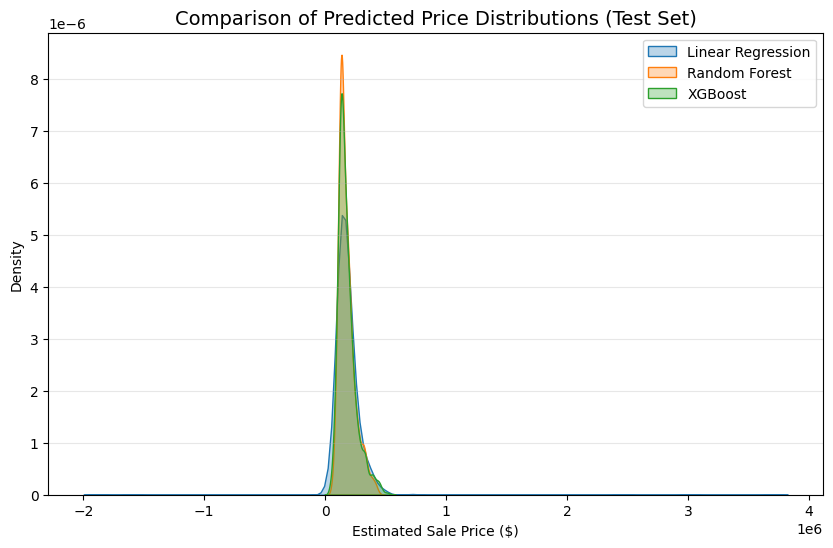

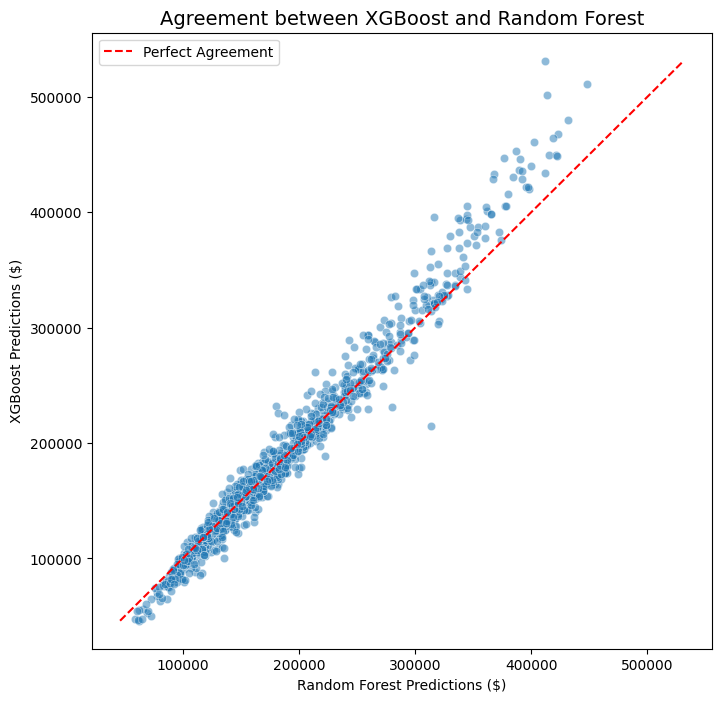

In [23]:
###########################################
#      FINAL PREDICTIONS COMPARISON       #
###########################################

import matplotlib.pyplot as plt
import seaborn as sns

# On crée un DataFrame de comparaison à partir de tes variables de soumission
final_comp = pd.DataFrame({
    'Linear_Reg': submission_lr['SalePrice'],
    'Random_Forest': submission_rf['SalePrice'],
    'XGBoost': submission_xgb['SalePrice']
})

# 1. Visualisation de la distribution des prédictions
plt.figure(figsize=(10, 6))
sns.kdeplot(final_comp['Linear_Reg'], label='Linear Regression', fill=True, alpha=0.3)
sns.kdeplot(final_comp['Random_Forest'], label='Random Forest', fill=True, alpha=0.3)
sns.kdeplot(final_comp['XGBoost'], label='XGBoost', fill=True, alpha=0.3)

plt.title('Comparison of Predicted Price Distributions (Test Set)', fontsize=14)
plt.xlabel('Estimated Sale Price ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Scatter Plot : XGBoost vs Random Forest (Les deux modèles les plus performants)
plt.figure(figsize=(8, 8))
sns.scatterplot(x=final_comp['Random_Forest'], y=final_comp['XGBoost'], alpha=0.5)

# Ligne de référence y=x
max_val = max(final_comp['Random_Forest'].max(), final_comp['XGBoost'].max())
min_val = min(final_comp['Random_Forest'].min(), final_comp['XGBoost'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement')

plt.title('Agreement between XGBoost and Random Forest', fontsize=14)
plt.xlabel('Random Forest Predictions ($)')
plt.ylabel('XGBoost Predictions ($)')
plt.legend()
plt.show()